### Prep data for decision tree

In [29]:
import pandas as pd

classification_df = pd.read_csv('data/diabetes_three_category.csv')
binary_df = pd.read_csv('data/diabetes_two_category.csv')

In [30]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# prep data 
classification_df = classification_df.sample(frac=1, random_state=42).reset_index(drop=True)
binary_df = binary_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Standard scaling before PCA for classification_df
features_class = classification_df.loc[:, classification_df.columns != 'Diabetes_012']
target_class = classification_df['Diabetes_012']
scaler_class = StandardScaler()
features_class_scaled = scaler_class.fit_transform(features_class)
pca_class = PCA(n_components=10, random_state=42)
features_class_pca = pca_class.fit_transform(features_class_scaled)
classification_df_pca = pd.DataFrame(features_class_pca)
classification_df_pca['Diabetes_012'] = target_class.values

# Standard scaling before PCA for binary_df
features_bin = binary_df.loc[:, binary_df.columns != 'Diabetes_binary']
target_bin = binary_df['Diabetes_binary']
scaler_bin = StandardScaler()
features_bin_scaled = scaler_bin.fit_transform(features_bin)
pca_bin = PCA(n_components=10, random_state=42)
features_bin_pca = pca_bin.fit_transform(features_bin_scaled)
binary_df_pca = pd.DataFrame(features_bin_pca)
binary_df_pca['Diabetes_binary'] = target_bin.values

# set aside 10% of data for part B
bin_train, bin_test = train_test_split(binary_df_pca, test_size=0.1, random_state=42)
class_train, class_test = train_test_split(classification_df_pca, test_size=0.1, random_state=42)

# split into 4 sets
classification_sets = [df.reset_index(drop=True) for df in np.array_split(class_train, 4)]
binary_sets = [df.reset_index(drop=True) for df in np.array_split(bin_train, 4)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

c_tree_df = classification_sets[0]
b_tree_df = binary_sets[0]

### Train binary classification tree

In [31]:
from sklearn.tree import DecisionTreeClassifier
# tree with full range of classifications
tree_class_accuracies = []
max_features = [0.2, 0.4, 0.6, 0.8, 1.0]
for features in max_features:
    accuracies_list = []
    for i, (train, test) in enumerate(kf.split(c_tree_df.loc[:, c_tree_df.columns != 'Diabetes_012'], c_tree_df['Diabetes_012'])):
        print(f"Fold {i+1}")
        print("TRAIN indices:", train)
        print("TEST indices:", test)

        X_tree_train = c_tree_df.loc[train, c_tree_df.columns != 'Diabetes_012']
        y_tree_train = c_tree_df.loc[train, 'Diabetes_012']

        X_tree_test = c_tree_df.loc[test, c_tree_df.columns != 'Diabetes_012']
        y_tree_test = c_tree_df.loc[test, 'Diabetes_012']

        tree_classifier = DecisionTreeClassifier(max_features=features, random_state=42)
        tree_classifier.fit(X_tree_train, y_tree_train)
        scores = tree_classifier.score(X_tree_test, y_tree_test)
        print(f"Accuracy of features = {features}: {scores}\n")
        accuracies_list.append(scores)
        
    tree_class_accuracies.append(accuracies_list)


Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of features = 0.2: 0.7737386124737211

Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy of features = 0.2: 0.7664681149264191

Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy of features = 0.2: 0.7727750525578136

Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy of features = 0.2: 0.7636443276390714

Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy of features = 0.2: 0.7660096364432764

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of features = 0.4: 0.7628766643

In [32]:
# binary version of tree
tree_bin_accuracies = []
max_features = [0.2, 0.4, 0.6, 0.8, 1.0]
for features in max_features:
    accuracies_list = []
    for i, (train, test) in enumerate(kf.split(c_tree_df.loc[:, c_tree_df.columns != 'Diabetes_012'], c_tree_df['Diabetes_012'])):
        print(f"Fold {i+1}")
        print("TRAIN indices:", train)
        print("TEST indices:", test)

        X_tree_train = c_tree_df.loc[train, c_tree_df.columns != 'Diabetes_012']
        y_tree_train = c_tree_df.loc[train, 'Diabetes_012']

        X_tree_test = c_tree_df.loc[test, c_tree_df.columns != 'Diabetes_012']
        y_tree_test = c_tree_df.loc[test, 'Diabetes_012']
        tree_classifier = DecisionTreeClassifier(max_features=features, random_state=42)
        tree_classifier.fit(X_tree_train, y_tree_train)
        scores = tree_classifier.score(X_tree_test, y_tree_test)
        print(f"Accuracy of features = {features}: {scores}\n")
        accuracies_list.append(scores)
        
    tree_bin_accuracies.append(accuracies_list)

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of features = 0.2: 0.7737386124737211

Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy of features = 0.2: 0.7664681149264191

Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy of features = 0.2: 0.7727750525578136

Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy of features = 0.2: 0.7636443276390714

Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy of features = 0.2: 0.7660096364432764

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of features = 0.4: 0.7628766643

### visualizations

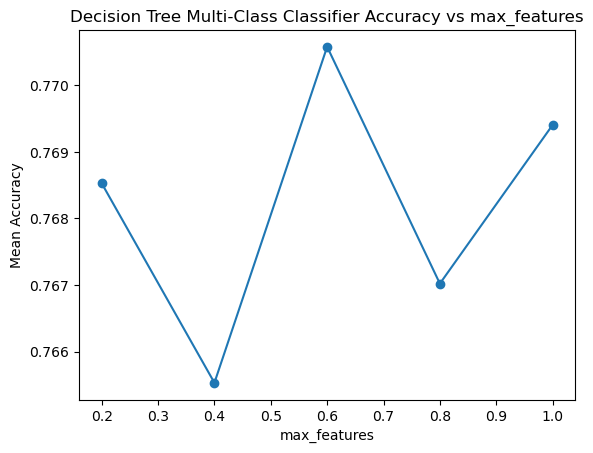

In [33]:
import matplotlib.pyplot as plt

# process results and plot
tree_class_mean_accuracies = [np.mean(acc) for acc in tree_class_accuracies]

plt.plot(max_features, tree_class_mean_accuracies, marker='o')
plt.title('Decision Tree Multi-Class Classifier Accuracy vs max_features')
plt.xlabel('max_features')
plt.ylabel('Mean Accuracy')
plt.show()

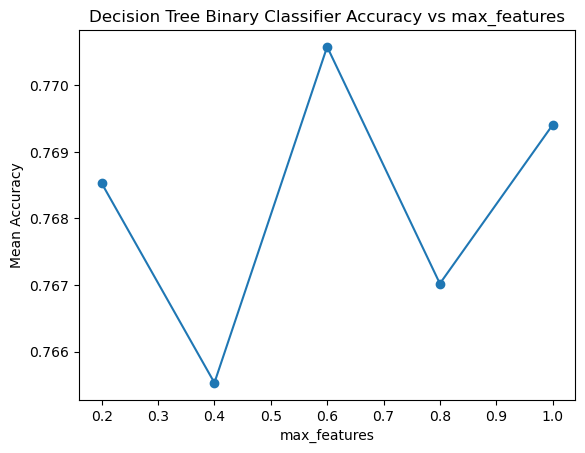

In [34]:
# process results and plot
tree_bin_mean_accuracies = [np.mean(acc) for acc in tree_bin_accuracies]

plt.plot(max_features, tree_bin_mean_accuracies, marker='o')
plt.title('Decision Tree Binary Classifier Accuracy vs max_features')
plt.xlabel('max_features')
plt.ylabel('Mean Accuracy')
plt.show()

### select + train best binary classfication tree model

In [35]:
# prep data for final training
best_bin_tree_max_features = 0.6
best_bin_tree_classifier = DecisionTreeClassifier(max_features=best_bin_tree_max_features, random_state=42)

In [36]:
# train and get runtime
best_bin_tree_classifier.fit(bin_train.loc[:, bin_train.columns != 'Diabetes_binary'], bin_train['Diabetes_binary'])

DecisionTreeClassifier(max_features=0.6, random_state=42)

In [37]:
# get performance
best_bin_tree_classifier.score(bin_train.loc[:, bin_train.columns != 'Diabetes_binary'], bin_train['Diabetes_binary'])

0.9939337397946669

In [38]:
# get performance
best_bin_tree_classifier.score(bin_test.loc[:, bin_test.columns != 'Diabetes_binary'], bin_test['Diabetes_binary'])

0.8013639230526648

### Get final performance and runtime of best multi-class tree model

In [39]:
# prep data for final training
best_class_tree_max_features = 0.6
best_class_tree_classifier = DecisionTreeClassifier(max_features=best_class_tree_max_features, random_state=42)

In [40]:
# train and get runtime
best_class_tree_classifier.fit(class_train.loc[:, class_train.columns != 'Diabetes_012'], class_train['Diabetes_012'])

DecisionTreeClassifier(max_features=0.6, random_state=42)

In [41]:
# training performance
best_class_tree_classifier.score(class_train.loc[:, class_train.columns != 'Diabetes_012'], class_train['Diabetes_012'])

0.9927818073513438

In [42]:
# testing performance
best_class_tree_classifier.score(class_test.loc[:, class_test.columns != 'Diabetes_012'], class_test['Diabetes_012'])

0.7749132765689057